# 1. Overview and coverage

<a href="https://colab.research.google.com/github/jmoortgat/GasBrineBench/blob/main/notebooks/01_overview_and_coverage.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


What is in GasBrineBench v1.2, where it sits in temperature and pressure, how it divides between gases and brines, how the quality
codes and modifier flags are distributed, and which papers contribute. Later notebooks look at each kind of data in turn.

All figures follow one convention: colour **and** marker (and line style) carry the same information, so they can be read in grayscale.
Quality codes: R = independently corroborated, T = tentative, U = uncertain. The *default view* drops rows with a flag that
`SCHEMA.md` lists as default-excluded (other gases, hydrate regime, no stated pressure, ...).

> **Running on Google Colab?** Click the badge above and run the cells; nothing needs to be installed. The first code cell detects
> Colab, clones the repository into `/content/GasBrineBench`, checks that pandas, numpy and matplotlib are present (Colab already has them)
> and changes into `notebooks/`, so everything after it works as on a local checkout. Locally the cell does nothing but confirm the layout.
> To use a fork or a branch, set `GBB_REPO_URL` and `GBB_BRANCH` before the cell runs.

In [1]:
# --- Colab / local bootstrap ---------------------------------------------------------------------------------
# On Colab this cell clones the repository and installs anything missing; on a local checkout it only confirms the layout.
# Re-running it is safe.
import os, subprocess, sys
from pathlib import Path

REPO_URL = os.environ.get("GBB_REPO_URL", "https://github.com/jmoortgat/GasBrineBench.git")
BRANCH = os.environ.get("GBB_BRANCH", "main")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB or os.environ.get("GBB_FORCE_BOOTSTRAP"):
    REPO_DIR = Path("/content/GasBrineBench") if IN_COLAB else Path(os.environ.get("GBB_CLONE_DIR", "GasBrineBench_clone")).resolve()
    if not REPO_DIR.exists():
        print(f"cloning {REPO_URL} ({BRANCH}) into {REPO_DIR}")
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f"repository already cloned at {REPO_DIR}")
    missing = []
    for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
        try:
            __import__(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("pip install -q", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    os.chdir(REPO_DIR / "notebooks")
    print("cwd =", os.getcwd())
else:
    print("local environment: using the existing checkout")

local environment: using the existing checkout


In [2]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
HERE = pathlib.Path.cwd()
ROOT = HERE if (HERE / "gasbrinebench").exists() else HERE.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "notebooks"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gasbrinebench as gbb
from gasbrinebench.vocab import DEFAULT_EXCLUDED_FLAGS
import gbb_viz as V
V.style()
# default view (what a benchmark user scores) and the view that also keeps rows without a stated pressure
df = gbb.load()
dfp = gbb.load(exclude_flags=tuple(f for f in DEFAULT_EXCLUDED_FLAGS if f != "pressure-unstated"))
dfall = gbb.load(exclude_tags=None, exclude_flags=None)
print(f"{len(dfall):,} rows in total, {len(df):,} in the default view, gasbrinebench {gbb.__version__}")

27,025 rows in total, 23,300 in the default view, gasbrinebench 1.2.0


## Rows per family

In [3]:
inv = gbb.inventory(dfall, by="family")
inv["default view"] = df.groupby("family").size()
display(inv[["rows", "default view", "sources", "gases", "T_min", "T_max", "P_min", "P_max", "R", "T", "U"]].fillna(0).round(2))

,rows,default view,sources,gases,T_min,T_max,P_min,P_max,R,T,U
family,,,,,,,,,,,
dh_sol,238,111.0,7,"1-c4h8, ar, c-c3h6, c2h2, c2h4, c2h6, c3h6, c3...",273.2,373.1,0.89,202.4,0,238,0
eps_r,13,0.0,1,-,298.2,298.2,1.00,1.0,0,13,0
phi_osm,717,337.0,11,-,298.2,573.2,0.39,85.9,0,717,0
psat_ratio,1402,1247.0,19,-,292.0,647.0,0.00,0.0,21,1381,0
rho,6180,6180.0,63,-,274.2,642.9,1.00,700.0,0,6180,0
rho_gas,951,951.0,4,co2,274.1,725.5,99.45,1008.1,0,951,0
solubility,14682,12111.0,164,"ar, c-c6h12, c2h2f4, c2h4, c2h4f2, c2h6, c3h8,...",272.8,773.2,0.10,3500.0,1424,13056,202
ternary,93,78.0,3,"ch4, co2, co2-ch4",323.2,423.2,19.11,1000.0,0,93,0
thermo_brine,692,657.0,8,-,278.2,602.7,1.01,200.0,0,692,0


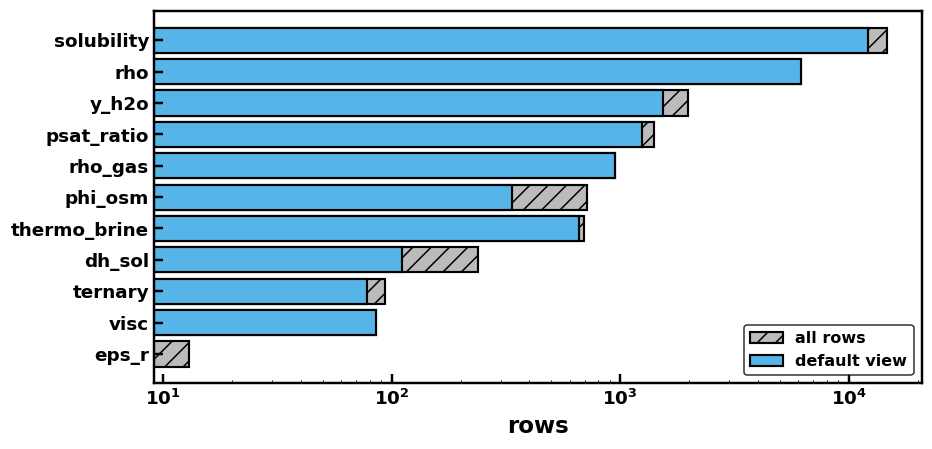

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.4))
order = inv.sort_values("rows").index
ax.barh(order, inv.loc[order, "rows"], color="#bbbbbb", edgecolor="black", linewidth=1.4, hatch="//", label="all rows")
ax.barh(order, inv.loc[order, "default view"].fillna(0), color="#56B4E9", edgecolor="black", linewidth=1.4, label="default view")
ax.set_xscale("log"); V.lab(ax, "rows", "")
ax.legend(loc="lower right"); plt.show()

## Where the data are in temperature and pressure

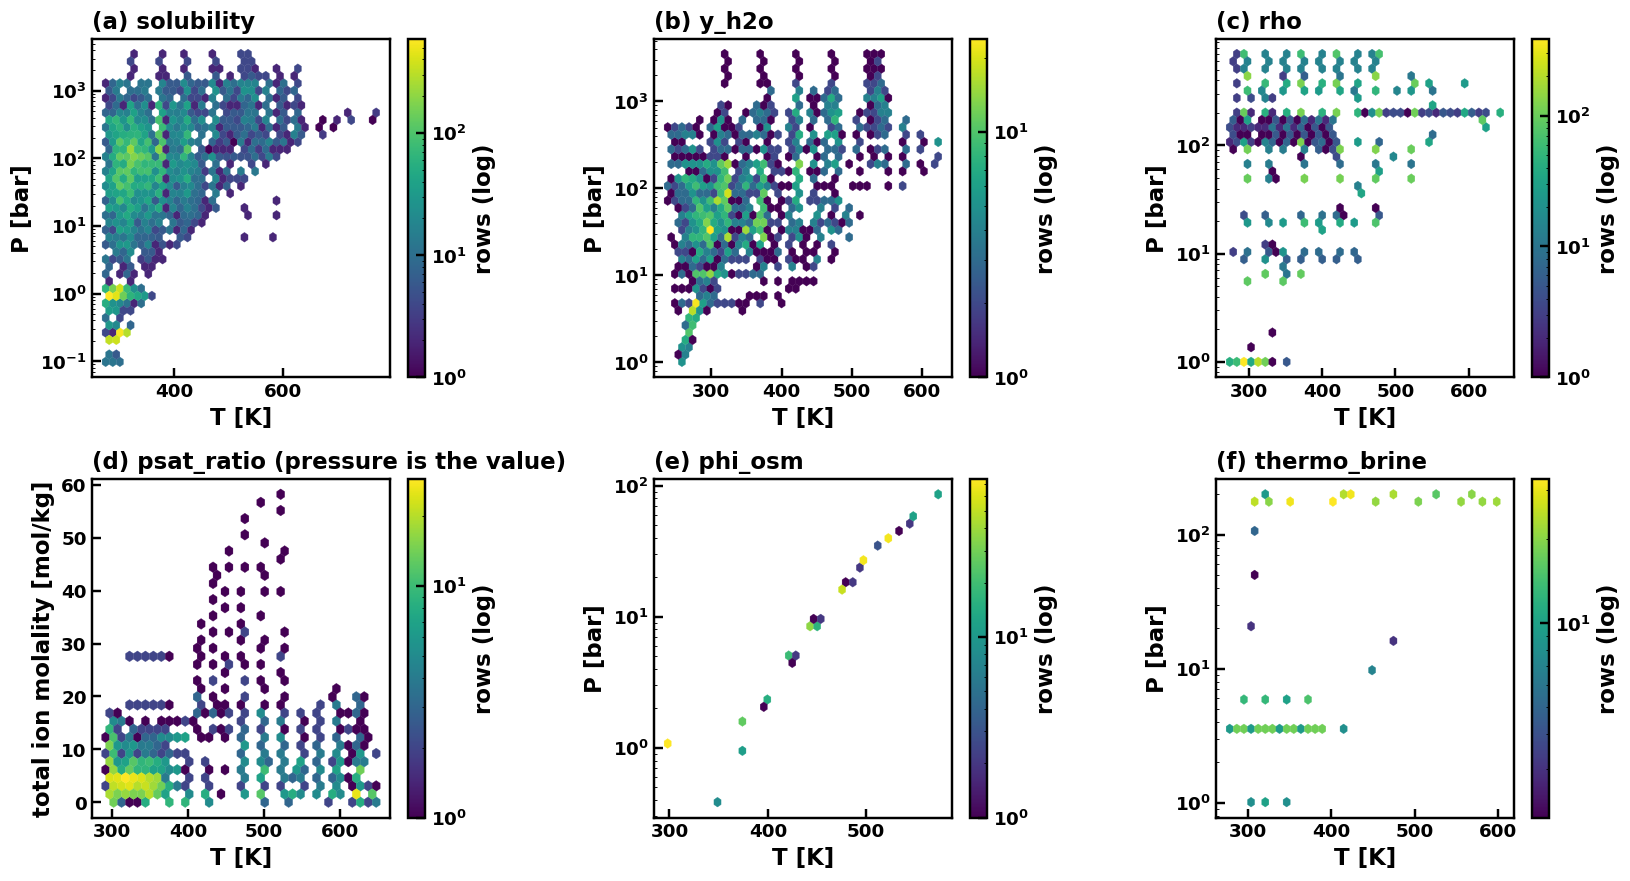

In [5]:
fams = ["solubility", "y_h2o", "rho", "psat_ratio", "phi_osm", "thermo_brine"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8.2), sharex=False)
for ax, f in zip(axes.ravel(), fams):
    g = dfall[(dfall.family == f)]
    p = g.P_bar.where(g.P_bar > 0)
    if f == "psat_ratio":
        m = gbb.total_molality(g)
        hb = ax.hexbin(g.T_K, m, gridsize=34, bins="log", cmap="viridis", mincnt=1, linewidths=0.2)
        plt.colorbar(hb, ax=ax, label="rows (log)")
        V.lab(ax, "T [K]", "total ion molality [mol/kg]", f"({chr(97 + fams.index(f))}) {f} (pressure is the value)")
        continue
    if p.notna().sum() == 0:
        ax.text(0.5, 0.5, "no pressure", ha="center", va="center", transform=ax.transAxes)
    else:
        hb = ax.hexbin(g.T_K[p.notna()], p[p.notna()], gridsize=38, yscale="log", bins="log", cmap="viridis", mincnt=1, linewidths=0.2)
        plt.colorbar(hb, ax=ax, label="rows (log)")
    V.lab(ax, "T [K]", "P [bar]", f"({chr(97 + fams.index(f))}) {f}")
plt.tight_layout(); plt.show()

## Gases and salts

Rows of gas solubility (`solubility_molality`) by gas and by salt system. A zero is a gap in the literature we could transcribe, and is as
informative as a count.

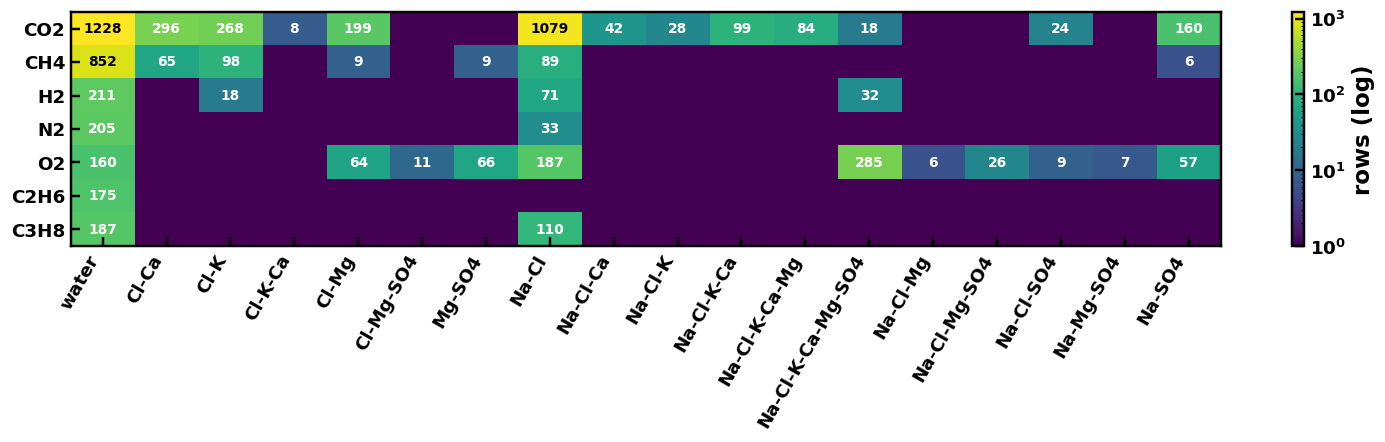

In [6]:
cov = gbb.coverage(gbb.load("solubility", property="solubility_molality"))
cov = cov.loc[[g for g in ["co2", "ch4", "h2", "n2", "o2", "c2h6", "c3h8"] if g in cov.index]]
fig, ax = plt.subplots(figsize=(14, 4.2))
from matplotlib.colors import LogNorm
im = ax.imshow(cov.values.clip(min=0.5), aspect="auto", cmap="viridis", norm=LogNorm(vmin=1, vmax=cov.values.max()))
ax.set_xticks(range(cov.shape[1])); ax.set_xticklabels(cov.columns, rotation=60, ha="right")
ax.set_yticks(range(cov.shape[0])); ax.set_yticklabels([V.GAS_LABEL[g] for g in cov.index])
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = int(cov.values[i, j])
        ax.text(j, i, str(v) if v else "", ha="center", va="center", fontsize=9, color="white" if v < 300 else "black")
plt.colorbar(im, ax=ax, label="rows (log)"); plt.tight_layout(); plt.show()

## Quality codes and modifier flags

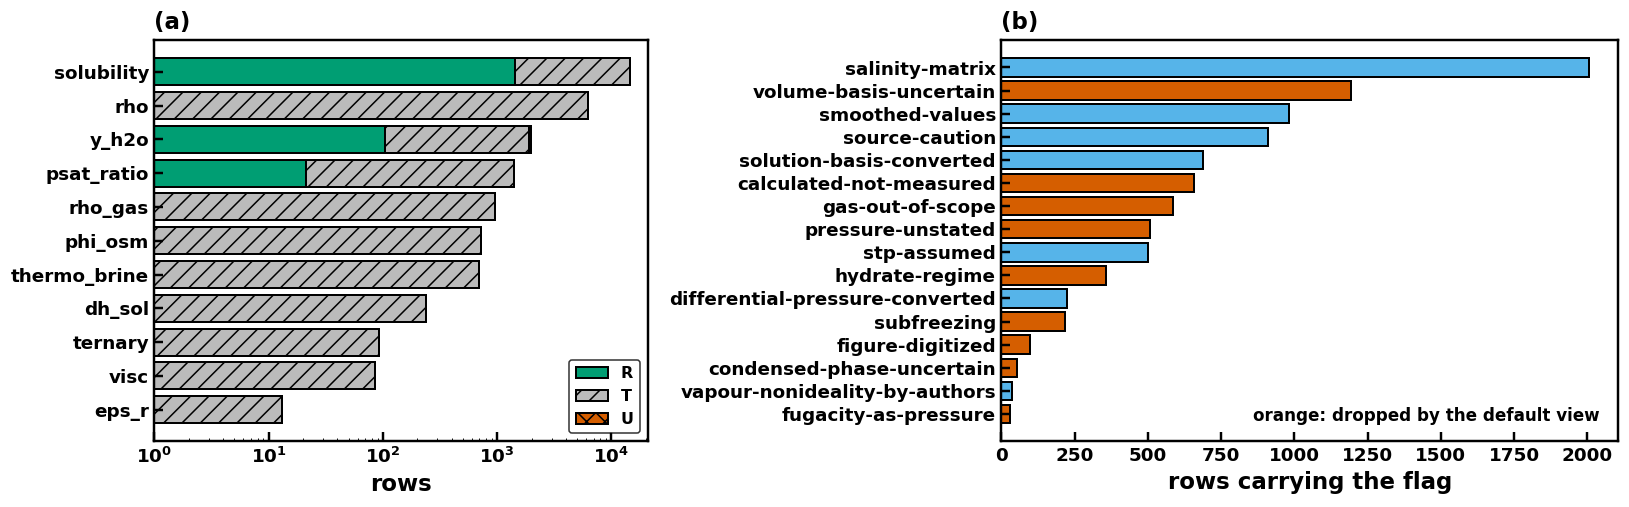

In [7]:
q = dfall.groupby(["family", "quality"]).size().unstack(fill_value=0).reindex(columns=["R", "T", "U"], fill_value=0)
q = q.loc[q.sum(axis=1).sort_values().index]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1, 1.25]})
left = np.zeros(len(q))
for k, (c, col, h) in enumerate([("R", "#009E73", ""), ("T", "#bbbbbb", "//"), ("U", "#D55E00", "xx")]):
    axes[0].barh(q.index, q[c], left=left, color=col, edgecolor="black", linewidth=1.3, hatch=h, label=c); left += q[c].values
axes[0].set_xscale("log"); axes[0].set_xlim(left=1); V.lab(axes[0], "rows", "", "(a)"); axes[0].legend(loc="lower right")
fl = dfall["flags"].str.split(";").explode()
fl = fl[fl != ""].value_counts().sort_values()
axes[1].barh(fl.index, fl.values, color=["#D55E00" if f in DEFAULT_EXCLUDED_FLAGS else "#56B4E9" for f in fl.index], edgecolor="black", linewidth=1.3)
V.lab(axes[1], "rows carrying the flag", "", "(b)")
axes[1].text(0.97, 0.05, "orange: dropped by the default view", transform=axes[1].transAxes, ha="right", fontsize=11)
plt.tight_layout(); plt.show()

## Which papers contribute, and when they were published

,rows
source,
ZEZIN(2014b),1339
ZEZIN(2014),740
MILLERO(2002b),639
DEBELIUS(2009),616
SONG(2014b),544
WANG(2019),504
SUSAK(1980),502
LIU(2021),434
CROZIER(1974),417


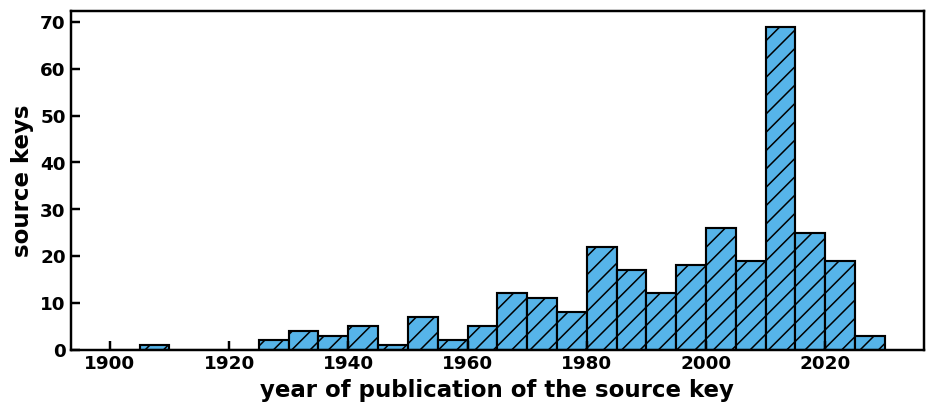

307 source keys; the 20 largest hold 36% of the rows


In [8]:
import re
src = dfall.groupby("source").size().sort_values(ascending=False)
display(src.head(20).to_frame("rows"))
yr = pd.Series([int(m.group(0)) if (m := re.search(r"(19|20)\d\d", s)) else np.nan for s in src.index]).dropna()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(yr, bins=np.arange(1900, 2031, 5), color="#56B4E9", edgecolor="black", linewidth=1.4, hatch="//")
V.lab(ax, "year of publication of the source key", "source keys"); plt.show()
print(f"{src.size} source keys; the 20 largest hold {src.head(20).sum() / src.sum():.0%} of the rows")